In [5]:
# ── Imports ──
# Dylan Crews V1 — logistic regression HR model
# Key notes:
#   - Age 24, Washington Nationals, bats R, RF
#   - MLB debut August 2024 — THIN SAMPLE (~1.5 seasons)
#   - Low HR volume expected — watch HR rate vs 16% threshold
#   - If AUC < 0.55, consistent with Henderson pattern: thin MLB sample is a hard constraint
#   - Nationals Park park_factor_hr = 125 — hitter friendly home park
#     road games in suppressive parks are where variance lives
#   - pitcher_r retained — bats right
#   - k_per_9 retained — young developing hitter
import sys
sys.path.append("../scripts")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sqlalchemy import text
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score
from pybaseball import statcast_batter
from data_collection import engine


In [6]:
# ── Load base dataset from database ──
# Dylan Crews player_id = 686611, team_id = 120 (Washington Nationals)
PLAYER_ID = 686611

with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT
            w.game_id,
            w.date,
            w.season,
            w.home_away,
            w.tb,
            w.hr,
            w.opponent_id,
            p.throws,
            p.era,
            p.k_per_9,
            pf.park_factor,
            pf.park_factor_hr
        FROM player_game_logs w
        JOIN pitcher_game_logs p ON w.game_id = p.game_id
        JOIN park_factors pf ON (
            CASE WHEN w.home_away = 'home' THEN 120
                 ELSE w.opponent_id
            END = pf.team_id
        )
        WHERE w.player_id = :pid
        ORDER BY w.date
    """), conn, params={"pid": PLAYER_ID})

print(f"Base dataset: {df.shape}")
print(df[['date', 'hr', 'tb', 'era']].head(10))


Base dataset: (116, 12)
         date  hr  tb   era
0  2024-08-26   0   0  4.00
1  2024-08-27   0   3  3.72
2  2024-08-28   1   6  4.16
3  2024-08-30   1   4  3.08
4  2024-08-31   0   1  3.15
5  2024-09-01   0   0  4.18
6  2024-09-03   0   1  5.44
7  2024-09-04   0   0  4.32
8  2024-09-05   0   1  4.41
9  2024-09-07   1   6  3.19


In [7]:
# ── HR distribution and base rate ──
print("HR distribution:")
print(df['hr'].value_counts().sort_index())

hr_rate = (df['hr'] >= 1).mean()
print(f"\nGames with 0 HR:  {(df['hr'] == 0).mean():.3f}")
print(f"Games with 1+ HR: {hr_rate:.3f} ({hr_rate*100:.1f}% of games)")
print(f"Games with 2+ HR: {(df['hr'] >= 2).mean():.3f}")

breakeven = -hr_rate / (1 - hr_rate) * 100
print(f"\nBreak-even American odds: {breakeven:.0f}")
print(f"\n(Witt: 16.0%, Julio: 17.4%, Greene: ~16.0% for comparison")
# Note: Crews thin MLB sample — HR rate may fall below 16% threshold
# If so, insufficient positive events is likely the failure mode


HR distribution:
hr
0    104
1     11
2      1
Name: count, dtype: int64

Games with 0 HR:  0.897
Games with 1+ HR: 0.103 (10.3% of games)
Games with 2+ HR: 0.009

Break-even American odds: -12

(Witt: 16.0%, Julio: 17.4%, Greene: ~16.0% for comparison


In [8]:
# ── Pull Statcast data via pybaseball ──
# Dylan Crews player_id = 686611
# MLB debut August 2024 — pulling from 2024 start, expect thin Statcast sample
print("Pulling Statcast data...")
statcast_raw = statcast_batter('2024-08-01', '2025-10-01', player_id=686611)
print(f"Statcast raw: {statcast_raw.shape}")


Pulling Statcast data...
Gathering Player Data
Statcast raw: (1940, 118)


In [9]:
# ── Aggregate Statcast to game level ──
batted = statcast_raw[statcast_raw['launch_speed'].notna()].copy()

# HR zone: 25-35 degree launch angle band — where balls most frequently leave the park
batted['in_hr_zone'] = batted['launch_angle'].between(25, 35).astype(int)

game_stats = batted.groupby('game_date').agg(
    avg_exit_velo=('launch_speed', 'mean'),
    barrel_count=('launch_speed_angle', lambda x: (x == 6).sum()),
    hard_hit_count=('launch_speed', lambda x: (x >= 95).sum()),
    hr_zone_count=('in_hr_zone', 'sum'),
    batted_balls=('launch_speed', 'count'),
).reset_index()

game_stats['barrel_rate']   = game_stats['barrel_count']   / game_stats['batted_balls']
game_stats['hard_hit_rate'] = game_stats['hard_hit_count'] / game_stats['batted_balls']
game_stats['hr_zone_rate']  = game_stats['hr_zone_count']  / game_stats['batted_balls']

print(f"Game-level Statcast: {game_stats.shape}")
print(game_stats[['game_date', 'barrel_rate', 'hr_zone_rate']].head(10))

Game-level Statcast: (112, 9)
    game_date  barrel_rate  hr_zone_rate
0  2024-08-26     0.000000      0.000000
1  2024-08-27     0.200000      0.000000
2  2024-08-28     0.333333      0.000000
3  2024-08-30     0.166667      0.166667
4  2024-08-31     0.000000      0.166667
5  2024-09-01     0.000000      0.000000
6  2024-09-03     0.000000      0.000000
7  2024-09-04     0.000000      0.000000
8  2024-09-05     0.000000      0.000000
9  2024-09-07     0.222222      0.222222


In [10]:
# ── Rolling Statcast features — 15-day window ──
game_stats = game_stats.sort_values('game_date').reset_index(drop=True)

game_stats['avg_exit_velo_15'] = game_stats['avg_exit_velo'].shift(1).rolling(15, min_periods=7).mean()
game_stats['barrel_rate_15']   = game_stats['barrel_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hard_hit_rate_15'] = game_stats['hard_hit_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hr_zone_rate_15']  = game_stats['hr_zone_rate'].shift(1).rolling(15, min_periods=7).mean()

print(game_stats[['game_date', 'barrel_rate_15', 'hr_zone_rate_15']].head(20))

     game_date  barrel_rate_15  hr_zone_rate_15
0   2024-08-26             NaN              NaN
1   2024-08-27             NaN              NaN
2   2024-08-28             NaN              NaN
3   2024-08-30             NaN              NaN
4   2024-08-31             NaN              NaN
5   2024-09-01             NaN              NaN
6   2024-09-03             NaN              NaN
7   2024-09-04        0.100000         0.047619
8   2024-09-05        0.087500         0.041667
9   2024-09-07        0.077778         0.037037
10  2024-09-08        0.092222         0.055556
11  2024-09-10        0.083838         0.073232
12  2024-09-11        0.076852         0.067130
13  2024-09-12        0.070940         0.061966
14  2024-09-13        0.065873         0.057540
15  2024-09-14        0.061481         0.064815
16  2024-09-15        0.061481         0.064815
17  2024-09-16        0.048148         0.064815
18  2024-09-17        0.025926         0.064815
19  2024-09-18        0.014815         0

In [11]:
# ── Merge Statcast into base dataset ──
game_stats['game_date'] = pd.to_datetime(game_stats['game_date'])
df['date'] = pd.to_datetime(df['date'])

df = df.merge(
    game_stats[['game_date', 'avg_exit_velo_15', 'barrel_rate_15',
                'hard_hit_rate_15', 'hr_zone_rate_15']],
    left_on='date',
    right_on='game_date',
    how='left'
)

print(f"After merge: {df.shape}")
print(df[['avg_exit_velo_15', 'barrel_rate_15', 'hr_zone_rate_15']].isnull().sum())

After merge: (116, 17)
avg_exit_velo_15    10
barrel_rate_15      10
hr_zone_rate_15     10
dtype: int64


In [12]:
# ── Feature engineering ──
df = df.sort_values('date').reset_index(drop=True)

df['is_home']   = (df['home_away'] == 'home').astype(int)
df['pitcher_r'] = (df['throws'] == 'R').astype(int)

# Crews bats right — pitcher_r direction uncertain, let model decide
# Nationals Park park_factor_hr = 125 — hitter friendly
# is_home expected positive, road games in suppressive parks reduce probability

# Drop rows missing Statcast rolling features only
df_model = df.dropna(subset=['avg_exit_velo_15', 'barrel_rate_15',
                              'hr_zone_rate_15']).reset_index(drop=True)

print(f"Model dataset: {df_model.shape}")


Model dataset: (106, 19)


In [13]:
# ── Define features and binary target ──
# Crews V1 — 9 features, same structure as Julio V2
# k_per_9 hypothesis: young developing hitter, high K/9 may meaningfully suppress HR rate
# Warning: small dataset may produce unstable coefficients and high CV variance
FEATURES = [
    # Crews contact quality
    'avg_exit_velo_15',
    'barrel_rate_15',
    'hard_hit_rate_15',
    'hr_zone_rate_15',
    # Game context
    'is_home',
    'pitcher_r',
    # Pitcher
    'era',
    'k_per_9',
    # Park
    'park_factor',
]

X = df_model[FEATURES]
y_binary = (df_model['hr'] >= 1).astype(int)

print(f"Features: {len(FEATURES)}")
print(f"Dataset: {X.shape}")
print(f"HR rate: {y_binary.mean():.3f} ({y_binary.sum()} HR games out of {len(y_binary)})")
print(f"\n(Witt: 0.160, Julio: 0.174, Greene: ~0.160 for comparison)")
# Dataset is smallest of all players tested — ~1.5 seasons
# Henderson failed at ~1.5 seasons too — low bar expectation here


Features: 9
Dataset: (106, 9)
HR rate: 0.094 (10 HR games out of 106)

(Witt: 0.160, Julio: 0.174, Greene: ~0.160 for comparison)


In [14]:
# ── Scale features ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES)

In [15]:
# ── Baseline ──
baseline_acc = 1 - y_binary.mean()
print(f"Baseline accuracy (always predict no HR): {baseline_acc:.3f}")
breakeven = -y_binary.mean() / (1 - y_binary.mean()) * 100
print(f"Break-even odds for HR prop: {breakeven:.0f}")

Baseline accuracy (always predict no HR): 0.906
Break-even odds for HR prop: -10


In [16]:
# ── Regularization tuning — grid search over C ──
# C controls regularization strength
# Low C = stronger regularization = simpler model, less overfit
# High C = weaker regularization = fits training data more closely
C_grid = [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    LogisticRegression(max_iter=500),
    param_grid={'C': C_grid},
    cv=tscv,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1
)

grid_search.fit(X_scaled, y_binary)

best_C   = grid_search.best_params_['C']
best_auc = grid_search.best_score_

print(f"Best C:        {best_C}")
print(f"Best CV AUC:   {best_auc:.3f}")
print()

results = pd.DataFrame(grid_search.cv_results_)
print(results[['param_C', 'mean_test_score', 'std_test_score']].round(4).to_string(index=False))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.1

Best C:        0.001
Best CV AUC:   nan

 param_C  mean_test_score  std_test_score
   0.001              NaN             NaN
   0.010              NaN             NaN
   0.050              NaN             NaN
   0.100              NaN             NaN
   0.250              NaN             NaN
   0.500              NaN             NaN
   1.000              NaN             NaN
   2.000              NaN             NaN
   5.000              NaN             NaN
  10.000              NaN             NaN


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


In [17]:
# ── Cross-validation with best C ──
model = grid_search.best_estimator_

cv_auc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='roc_auc')
cv_acc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='accuracy')

print(f"CV AUC per fold:  {[round(v,3) for v in cv_auc]}")
print(f"CV ACC per fold:  {[round(v,3) for v in cv_acc]}")
print(f"\nAUC mean +/- std: {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}")
print(f"ACC mean +/- std: {cv_acc.mean():.3f} +/- {cv_acc.std():.3f}")
print(f"\nBaseline ACC:     {baseline_acc:.3f}")
print(f"Improvement:      {cv_acc.mean() - baseline_acc:.3f}")
print(f"\nJulio V2 CV AUC:     0.566")
print(f"Crews V1 CV AUC:     {cv_auc.mean():.3f}")
print(f"Witt V10 CV AUC: 0.567")
print(f"\n(AUC > 0.55 = meaningful signal for sports betting)")


CV AUC per fold:  [np.float64(nan), np.float64(0.238), np.float64(0.214), np.float64(0.375), np.float64(0.533)]
CV ACC per fold:  [np.float64(1.0), np.float64(0.824), np.float64(0.824), np.float64(0.941), np.float64(0.882)]

AUC mean +/- std: nan +/- nan
ACC mean +/- std: 0.894 +/- 0.069

Baseline ACC:     0.906
Improvement:      -0.012

Julio V2 CV AUC:     0.566
Crews V1 CV AUC:     nan
Witt V10 CV AUC: 0.567

(AUC > 0.55 = meaningful signal for sports betting)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [18]:
# ── Fit on full dataset ──
model.fit(X_scaled, y_binary)
df_model['p_hr'] = model.predict_proba(X_scaled)[:, 1]

insample_auc = roc_auc_score(y_binary, df_model['p_hr'])
insample_acc = accuracy_score(y_binary, model.predict(X_scaled))

print(f"In-sample AUC:  {insample_auc:.3f}")
print(f"In-sample ACC:  {insample_acc:.3f}")
print(f"CV AUC:         {cv_auc.mean():.3f}")
print(f"\nGap (in-sample - CV AUC): {insample_auc - cv_auc.mean():.3f}")
print("(smaller gap = less overfitting)")
print(f"\nMean P(HR):     {df_model['p_hr'].mean():.3f}")
print(f"Actual HR rate: {y_binary.mean():.3f}")

In-sample AUC:  0.700
In-sample ACC:  0.906
CV AUC:         nan

Gap (in-sample - CV AUC): nan
(smaller gap = less overfitting)

Mean P(HR):     0.094
Actual HR rate: 0.094


In [19]:
# ── Calibration table ──
df_model['pred_bin'] = pd.qcut(df_model['p_hr'], q=5, labels=False)

calibration = df_model.groupby('pred_bin').agg(
    mean_predicted=('p_hr', 'mean'),
    actual_rate=('hr', lambda x: (x >= 1).mean()),
    n=('hr', 'count')
).round(3)

print(calibration)
spread = calibration['actual_rate'].iloc[-1] - calibration['actual_rate'].iloc[0]
print(f"\nSpread (bin 4 - bin 0): {spread:.3f}")
print(f"V6 spread:              0.185")
print(f"V5 spread:              ~0.12")
print("\n(larger spread = better discrimination between HR and non-HR games)")

          mean_predicted  actual_rate   n
pred_bin                                 
0                  0.093        0.091  22
1                  0.094        0.000  21
2                  0.094        0.095  21
3                  0.095        0.048  21
4                  0.095        0.238  21

Spread (bin 4 - bin 0): 0.147
V6 spread:              0.185
V5 spread:              ~0.12

(larger spread = better discrimination between HR and non-HR games)


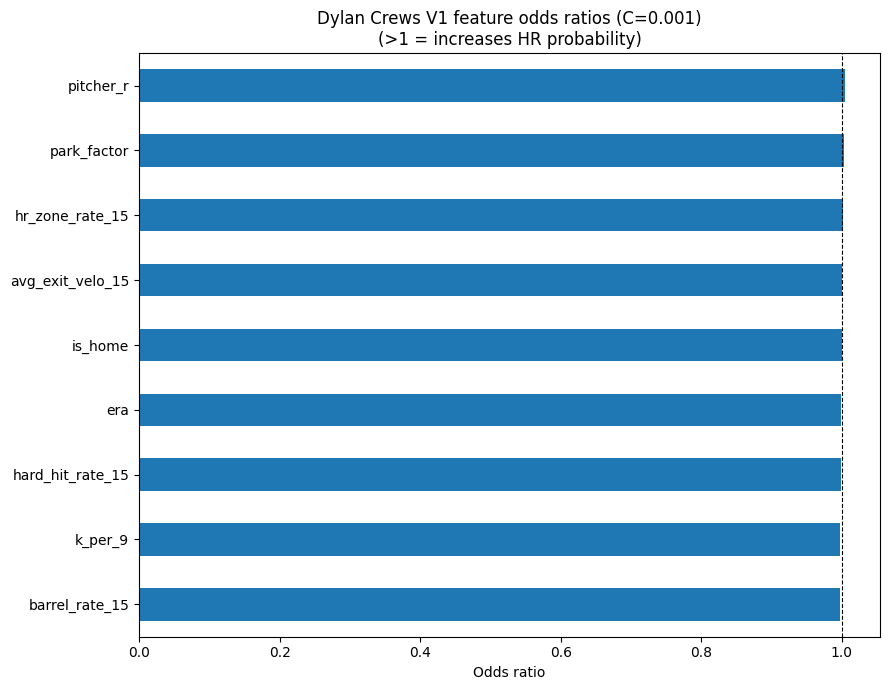


Odds ratios:
barrel_rate_15      0.998
k_per_9             0.998
hard_hit_rate_15    0.998
era                 0.999
is_home             1.000
avg_exit_velo_15    1.001
hr_zone_rate_15     1.003
park_factor         1.004
pitcher_r           1.004
dtype: float64


In [20]:
# ── Feature odds ratios ──
# Expected directions:
#   era        > 1 — higher ERA = worse pitcher = more HRs
#   k_per_9    < 1 — strikeout pitchers limit balls in play
#   park_factor > 1 — T-Mobile is 91, road games in hitter parks clearly better
#   pitcher_r  uncertain — Julio bats right
#   is_home    < 1 — T-Mobile suppresses HRs
coefs = pd.Series(model.coef_[0], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
np.exp(coefs).sort_values().plot(kind='barh', ax=ax)
ax.axvline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(f'Dylan Crews V1 feature odds ratios (C={best_C})\n(>1 = increases HR probability)')
ax.set_xlabel('Odds ratio')
plt.tight_layout()
plt.show()

print("\nOdds ratios:")
print(np.exp(coefs).round(3))


In [21]:
# ── Implied odds converter ──
def prob_to_american_odds(p):
    if p >= 0.5:
        return round(-p / (1 - p) * 100)
    else:
        return round((1 - p) / p * 100)

sample = df_model[['date', 'hr', 'p_hr']].copy()
sample['implied_odds'] = sample['p_hr'].apply(prob_to_american_odds)
sample['result'] = (sample['hr'] >= 1).map({True: '✅ HR', False: '❌ No HR'})

print("Last 20 games — model probability vs actual result:")
print(sample[['date', 'p_hr', 'implied_odds', 'result']].tail(20).to_string())

Last 20 games — model probability vs actual result:
          date      p_hr  implied_odds   result
86  2025-09-06  0.094112           963  ❌ No HR
87  2025-09-07  0.094212           961  ❌ No HR
88  2025-09-08  0.095003           953     ✅ HR
89  2025-09-09  0.094933           953  ❌ No HR
90  2025-09-10  0.094893           954  ❌ No HR
91  2025-09-11  0.094242           961  ❌ No HR
92  2025-09-12  0.095565           946     ✅ HR
93  2025-09-13  0.095245           950  ❌ No HR
94  2025-09-15  0.095062           952  ❌ No HR
95  2025-09-16  0.094665           956  ❌ No HR
96  2025-09-16  0.094156           962  ❌ No HR
97  2025-09-17  0.095157           951  ❌ No HR
98  2025-09-19  0.094981           953  ❌ No HR
99  2025-09-20  0.094614           957  ❌ No HR
100 2025-09-21  0.093464           970  ❌ No HR
101 2025-09-22  0.093742           967     ✅ HR
102 2025-09-23  0.094734           956  ❌ No HR
103 2025-09-24  0.094563           957  ❌ No HR
104 2025-09-26  0.094520           9

In [22]:
# ── Save model artifacts ──
joblib.dump(model,  '../models/crews_hr_logistic_v1_model.pkl')
joblib.dump(scaler, '../models/crews_hr_logistic_v1_scaler.pkl')
print("Saved:")
print("  models/crews_hr_logistic_v1_model.pkl")
print("  models/crews_hr_logistic_v1_scaler.pkl")
print(f"\nBest C: {best_C}")
print(f"Features ({len(FEATURES)}): {FEATURES}")


Saved:
  models/crews_hr_logistic_v1_model.pkl
  models/crews_hr_logistic_v1_scaler.pkl

Best C: 0.001
Features (9): ['avg_exit_velo_15', 'barrel_rate_15', 'hard_hit_rate_15', 'hr_zone_rate_15', 'is_home', 'pitcher_r', 'era', 'k_per_9', 'park_factor']
